# Lab 1 Task 2

In [1]:
!pip install thop
!pip install torchsummary

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import argparse
import os
import numpy as np
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter
from thop import profile
from torchsummary import summary

In [3]:
# Check if CUDA is available
print(torch.cuda.is_available())

True


In [4]:
# Calculate mean and std of dataset
def get_mean_std(dataset, ratio=1):
    # Get mean and std by sample ratio
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=int(len(dataset)*ratio), shuffle=True, num_workers=2)

    data = next(iter(dataloader))[0]     # get the first iteration data
    mean = np.mean(data.numpy(), axis=(0,2,3))
    std = np.std(data.numpy(), axis=(0,2,3))
    return mean, std

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

train_mean, train_std = get_mean_std(train_dataset)
test_mean, test_std = train_mean, train_std
print(train_mean, train_std)
print(test_mean, test_std)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


[0.4914016 0.482159  0.4465312] [0.2470319  0.2434848  0.26158807]
[0.4914016 0.482159  0.4465312] [0.2470319  0.2434848  0.26158807]


In [5]:
##### data augmentation & normalization #####
transform_train = transforms.Compose([
    # 同學實作部分：Add data augmentation here
    transforms.RandomCrop(32, padding=4),  # 裁切
    transforms.RandomHorizontalFlip(),  #旋轉
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(), # Transform to tensor
    transforms.Normalize(mean=train_mean, std=train_std), # Normalization
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=test_mean, std=test_std),
])

In [6]:
# Dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

image, label = trainset[0]
print("image shape: ", image.shape)

# Split validation dataset
torch.manual_seed(43)     # Ensure reproducibility
val_size = 5000       # Take 5000 images as validation set
train_size = len(trainset) - val_size
train_ds, val_ds = random_split(trainset, [train_size, val_size])
print("train length: ", len(train_ds))
print("val length: ", len(val_ds))
print("test length: ", len(test_ds))

# Declare batch size
# 學生實作部分：Set batch size
BATCH_SIZE = 128
trainloader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

image shape:  torch.Size([3, 32, 32])
train length:  45000
val length:  5000
test length:  10000


In [7]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        # 學生實作部分：Define the two convolutional layers and the shortcut connection
        #defines two consecutive convolutional layers within the residual block
        #H(x) = F(x) + x

        #這裡是F(x) 的部分
        #一個Residual block包含兩個捲積層
        self.left = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        #這裡是x的部分
        #Channel數不同時
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            #shortcut, in order to maintain consistency with the structure of the two convolutional layers' results, some processing is required here.
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )


    def forward(self, x):
        # 學生實作部分：Define the forward pass using convolutional layers and the shortcut connection
        out = self.left(x)
        #Adding the outputs of the two convolutional layers to the processed x achieves the fundamental structure of ResNet
        #實際做到H(x) = F(x) + x
        out = out + self.shortcut(x)
        out = F.relu(out)

        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=1000):
        super(ResNet18, self).__init__()
        # 學生實作部分：Define the ResNet-18 architecture using BasicBlock
        #記錄目前輸入 feature map 的 channel數
        self.in_channels = 64
        #stem 層 或 前置特徵提取層
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # make layers
        # 每一個 layer 裡面會包含多個 ResBlock
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        # 學生實作部分：Define make_layer function to create layers of blocks
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(block(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        # 學生實作部分：Define the forward pass of ResNet-18
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = F.avg_pool2d(out, 4)  # 專屬CIFAR10的
        #out = self.avgpool(out)  # 加了這兩行去自動適應任何輸入大小(224*224 或 32*32)
        #out = torch.flatten(out, 1)

        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


In [8]:
# Create SummaryWriter
writer = SummaryWriter("../tensorboard")

model = ResNet18(num_classes=10)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Print model summary
#summary(model, (3, 224, 224))  # ImageNet的size
summary(model, (3, 32, 32))  # CIFAR10的size

# Calculate FLOPs and Params
dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy_input, ))
print(f"FLOPs: {flops/1e6:.2f} MFLOPs")
print(f"Params: {params/1e6:.2f} M")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          36,864
       BatchNorm2d-8           [-1, 64, 32, 32]             128
        BasicBlock-9           [-1, 64, 32, 32]               0
           Conv2d-10           [-1, 64, 32, 32]          36,864
      BatchNorm2d-11           [-1, 64, 32, 32]             128
             ReLU-12           [-1, 64, 32, 32]               0
           Conv2d-13           [-1, 64, 32, 32]          36,864
      BatchNorm2d-14           [-1, 64,

In [10]:
# Setting parameter
EPOCH = 30
pre_epoch = 0
lr = 0.01

# 同學可以根據自己需求調整optimizer, criterion與lr_scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
# Scheduler不見
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCH)  # 學習率調整策略 # 訓練過程中，學習率要隨著 epoch 慢慢降低，這樣模型在後期能更穩定收斂

best_model_path = 'best_model_resnet18.pth'

# Record training and validation metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

# Training and validation loop
for epoch in range(pre_epoch, EPOCH):
    model.train()
    train_running_loss = 0.0
    train_correct = 0
    train_total = 0
    # 學生實作部分：Complete the training and validation loop

    for data in trainloader:
          inputs, labels = data
          inputs, labels = inputs.to(device), labels.to(device)

          # 初始化梯度
          optimizer.zero_grad()

          # 前向傳播
          outputs = model(inputs)
          loss = criterion(outputs, labels)

          # 反向傳播與優化
          loss.backward()
          optimizer.step()

          # 累積損失
          train_running_loss += loss.item()

          # 計算訓練準確率
          _, predicted = outputs.max(1)
          train_total += labels.size(0)
          train_correct += predicted.eq(labels).sum().item()

    train_loss = train_running_loss / len(trainloader)
    train_acc = 100. * train_correct / train_total

    # 記錄訓練損失和準確率
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # 驗證模型
    model.eval()  # 讓 dropout/BatchNorm 進入 eval 模式（關閉 dropout、使用 running stats）

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad(): # 不計算梯度以節省記憶體與運算
      for data in valloader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item()

        _, predicted = outputs.max(1)
        val_total += labels.size(0)
        val_correct += predicted.eq(labels).sum().item()

      val_loss = val_running_loss / len(valloader)
      val_acc = 100. * val_correct / val_total

      # 記錄驗證損失和準確率
      val_losses.append(val_loss)
      val_accuracies.append(val_acc)


    # 印出每個 epoch 的 summary
    print(f"Epoch [{epoch+1}/{EPOCH}] "
      f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || "
      f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% " )

    # 儲存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    # 更新 scheduler（StepLR: 每 epoch 呼叫一次）
    scheduler.step()

print('Finished Training')

# load 你的best model再跑一次testloader
model.load_state_dict(torch.load(best_model_path))


Epoch [1/30] Train Loss: 1.6708 | Train Acc: 38.20% || Val Loss: 1.7954 | Val Acc: 36.12% 
Epoch [2/30] Train Loss: 1.3768 | Train Acc: 50.21% || Val Loss: 1.2996 | Val Acc: 53.04% 
Epoch [3/30] Train Loss: 1.1451 | Train Acc: 59.36% || Val Loss: 1.0978 | Val Acc: 59.16% 
Epoch [4/30] Train Loss: 0.9876 | Train Acc: 65.05% || Val Loss: 0.9842 | Val Acc: 64.82% 
Epoch [5/30] Train Loss: 0.8707 | Train Acc: 69.14% || Val Loss: 0.8849 | Val Acc: 68.54% 
Epoch [6/30] Train Loss: 0.7623 | Train Acc: 73.17% || Val Loss: 0.8110 | Val Acc: 71.84% 
Epoch [7/30] Train Loss: 0.6855 | Train Acc: 76.02% || Val Loss: 0.7089 | Val Acc: 75.48% 
Epoch [8/30] Train Loss: 0.6186 | Train Acc: 78.41% || Val Loss: 0.6897 | Val Acc: 76.62% 
Epoch [9/30] Train Loss: 0.5783 | Train Acc: 79.86% || Val Loss: 0.6789 | Val Acc: 75.84% 
Epoch [10/30] Train Loss: 0.5313 | Train Acc: 81.49% || Val Loss: 0.5942 | Val Acc: 79.42% 
Epoch [11/30] Train Loss: 0.4976 | Train Acc: 82.58% || Val Loss: 0.5927 | Val Acc: 79.08

<All keys matched successfully>

In [11]:
# Load the best model and evaluate on the test set
model.eval()

test_correct = 0
test_total = 0
with torch.no_grad():
    for test_inputs, test_labels in testloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)
        test_outputs = model(test_inputs)
        _, test_predicted = test_outputs.max(1)
        test_total += test_labels.size(0)
        test_correct += test_predicted.eq(test_labels).sum().item()
test_accuracy = 100. * test_correct / test_total
print(f"Best Model Test Accuracy: {test_accuracy:.2f}%")

Best Model Test Accuracy: 90.09%


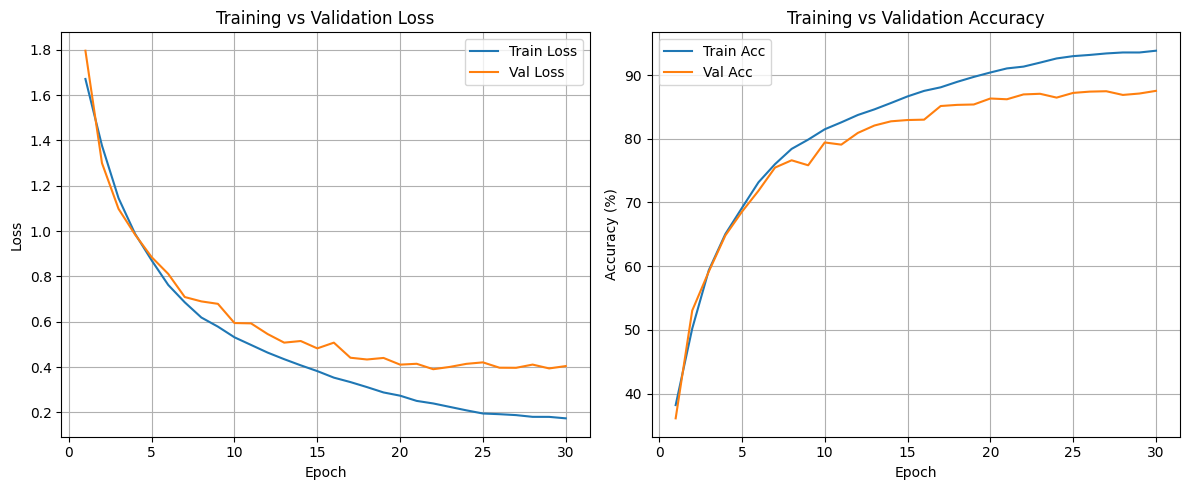

In [12]:
##### Plot loss & accuracy graph #####
import matplotlib.pyplot as plt
# 學生實作部分：Plot training and validation loss and accuracy curves

epochs = range(1, EPOCH + 1)

plt.figure(figsize=(12,5))

# --- Loss 曲線 ---
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# --- Accuracy 曲線 ---
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label='Train Acc')
plt.plot(epochs, val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()